# Simple PCA Demonstration

This notebook demonstrates Principal Component Analysis (PCA) focusing on its primary use: **Dimensionality Reduction**. 

We will skip the complex math and see how PCA takes a dataset with many dimensions and reduces it to fewer dimensions while retaining most of the important information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

## 1. Load the Data
We will use the **Digits dataset** from scikit-learn. Each data point is an 8x8 image of a digit, which means it has $8 \times 8 = 64$ pixels (dimensions).

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print(f"Data shape BEFORE PCA: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of dimensions (features): {X.shape[1]}")

Data shape BEFORE PCA: (1797, 64)
Number of samples: 1797
Number of dimensions (features): 64


As we can see, we have **64 dimensions**. It is impossible to visualize 64-dimensional data directly. Let's use PCA to reduce this down to 2 dimensions so we can plot it.

In [5]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

## 2. Apply PCA
First, it's usually a good idea to scale our data before applying PCA.

In [3]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit and transform the data
X_pca = pca.fit_transform(X_scaled)

print(f"Data shape AFTER PCA: {X_pca.shape}")
print(f"Number of dimensions (features) now: {X_pca.shape[1]}")

Data shape AFTER PCA: (1797, 2)
Number of dimensions (features) now: 2


Awesome! We reduced the data from **64 dimensions** down to just **2 dimensions**.

## 3. Visualize the Reduced Data
Now that our data is 2D, we can easily plot it on a standard scatter plot.

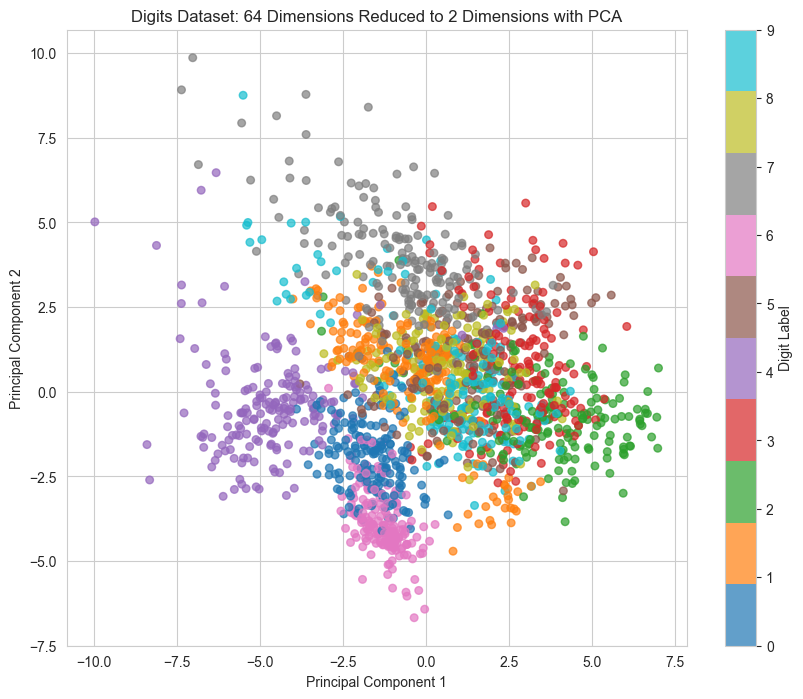

In [4]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=30)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Digits Dataset: 64 Dimensions Reduced to 2 Dimensions with PCA')
plt.show()

## Summary
- **Before PCA**: Data had 64 dimensions. Hard to visualize, potentially slow to train models on.
- **After PCA**: Data has 2 dimensions. Easy to plot, and we can clearly see that digits with the same label tend to cluster together, meaning PCA successfully captured the most important patterns in those 64 original dimensions and squeezed them into just 2.